# Direct Collocation for a Pendulum Swing-Up

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/rlbook/blob/main/lab/notebooks/08_collocation_from_nodes.ipynb)

This demo applies the direct-collocation recipe of the chapter
[Continuous-Time Transcription and Collocation](https://pierrelux.github.io/rlbook/continuous-time-collocation) to a small nonlinear
control problem. The chapter develops the recipe for general dynamics and
general choices of nodes. Here every step is carried out once with concrete
numbers and then written as a few lines of Python, so that each symbol of the
recipe can be matched with a quantity in the code. The text explains why each
step is needed as well as what it computes.

The demo runs in about half a minute with NumPy, SciPy, and Matplotlib and
needs no other files. Run the cells in order.

## The Problem

A pendulum hangs at rest below its pivot, where a motor applies a torque
$u(t)$. At time $T=8$ the pendulum must stand upright and at rest, and the
motor should use as little torque as possible. Let $\theta$ be the angle
measured from the hanging position and $\omega$ the angular velocity. Time is
measured in units of $\sqrt{\ell/g}$ and torque in units of $mg\ell$, where
$m$ is the mass, $\ell$ the length, and $g$ the gravitational acceleration.
In these units the state $\mathbf x=(\theta,\omega)$ evolves according to

$$
\dot\theta=\omega,\qquad \dot\omega=-\sin\theta+u.
$$

The term $-\sin\theta$ is gravity, which pulls the pendulum back toward the
hanging position. Its largest magnitude is $1$, reached when the pendulum is
horizontal. The motor is weak: its torque is limited to
$|u(t)|\le u_{\max}=0.5$, half of that largest gravity torque. It cannot lift
the pendulum directly, and it must swing it back and forth to build up energy,
which takes time. Writing the dynamics as
$\dot{\mathbf x}=\mathbf f(\mathbf x,u)$, the optimal control problem is

$$
\min_{\mathbf x(\cdot),u(\cdot)} \int_0^T u(t)^2 dt
\quad\text{subject to}\quad
\dot{\mathbf x}=\mathbf f(\mathbf x,u),\quad
|u(t)|\le u_{\max},\quad
\mathbf x(0)=(0,0),\quad
\mathbf x(T)=(\pi,0).
$$

Because of $\sin\theta$, the dynamics are nonlinear, and neither the optimal
torque nor the resulting motion has a closed-form expression.

## From Functions to Numbers

SciPy's `minimize`, like every nonlinear programming solver, works with a
finite vector $\mathbf z$ of unknowns. It needs a function $F(\mathbf z)$ that
returns the objective and a function $H(\mathbf z)$ that returns constraint
residuals, which must be zero at a solution. The problem above provides
neither. Its unknowns are the functions $\theta(t)$, $\omega(t)$, and $u(t)$,
its constraint is a condition on a derivative at every instant, and its
objective is an integral. Transcription replaces these objects by finitely
many numbers and algebraic equations.

Direct collocation makes three replacements:

1. The horizon is divided into $N$ intervals, and on each interval the state
   is described by a polynomial. A polynomial of low degree is determined by a
   few numbers, and its derivative and integral can be computed exactly from
   those numbers.
2. The differential equation is required only at a few chosen times per
   interval, the **collocation nodes**, where the slope of the polynomial must
   equal the slope given by $\mathbf f$.
3. The cost integral is replaced by a weighted sum of cost rates at the same
   nodes.

After these replacements, every condition is an equation between numbers,
which the optimizer can evaluate for any candidate $\mathbf z$.

Many short intervals are used instead of one polynomial over $[0,T]$. This
keeps the degree of each polynomial low, lets the accuracy improve by adding
intervals, and makes each equation involve only the numbers of one interval.

The sections below follow the steps of the chapter's
[integration-form algorithm](https://pierrelux.github.io/rlbook/continuous-time-collocation#alg-collocation-from-nodes). Step 1
computes fixed numbers that describe the polynomials. Steps 2 to 4 define
$\mathbf z$, $F$, and $H$. Step 5 solves the problem and checks the answer
against an accurate simulation. A final section builds the same problem from
derivatives instead of integrals.

The first cell defines the model. The rest of the demo uses the dynamics only
through calls `f(x, u)` and the cost only through calls `c(x, u)`, so another
model would change only this cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from numpy.polynomial import Polynomial
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


def f(x, u):
    # Pendulum dynamics: x = (angle, angular velocity), u = torque.
    theta, omega = x
    return np.array([omega, -np.sin(theta) + u])


def c(x, u):
    # Running cost rate.
    return u**2


T = 8.0                            # horizon
u_max = 0.5                        # torque limit
x_start = np.array([0.0, 0.0])     # hanging, at rest
x_goal = np.array([np.pi, 0.0])    # upright, at rest

## Step 1: Compute the Rule Once

Divide $[0,T]$ into $N$ intervals of width $h=T/N$, so that interval $k$ runs
from $t_k=kh$ to $t_{k+1}=t_k+h$. Inside interval $k$, measure time by the
**local time** $\tau=(t-t_k)/h$, which runs from $0$ at the left end to $1$ at
the right end. Every interval then looks the same in local time, so the
numbers computed in this step on $[0,1]$ serve every interval, whatever its
position and width.

Three symbols for local time appear below, and they play different roles. The
letter $\tau$ stands for any point of the interval. The **collocation nodes**
$\tau_1$ and $\tau_2$ are two fixed values of $\tau$, chosen once and used in
every interval. This demo uses $\tau_1=\tfrac{1}{3}$ and $\tau_2=1$, called
the two-stage Radau nodes. The letter $\sigma$ is the variable of integration
in the integrals below, which run from $0$ to some value of $\tau$. The sketch
below shows what the method builds. The state trajectory consists of one
polynomial piece per interval. Consecutive pieces meet at the mesh states,
although their slopes may differ there. Inside each interval, the stage states
sit at the nodes, where the slope of the piece must equal the slope given by
$\mathbf f$. The torque is constant on each interval. The right panel shows
interval $k$ in local time, with the quantities that Step 2 turns into
unknowns. The trajectory in the sketch is made up for illustration; the
pendulum's trajectory appears in Step 5.

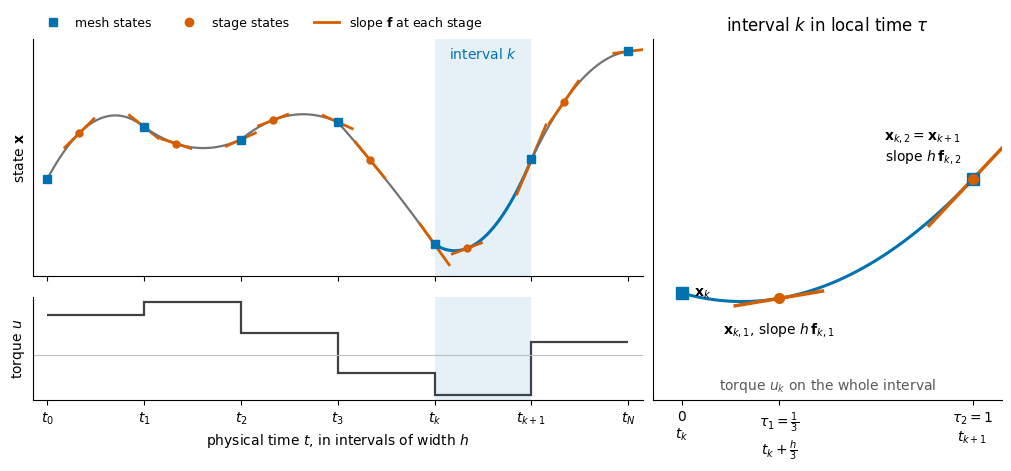

In [2]:
# @title Sketch a collocation trajectory and one interval in local time
def wiggle(t):                            # a made-up smooth trajectory, for the sketch only
    return 0.6 * np.sin(1.1 * t) + 0.35 * np.sin(2.4 * t + 0.8) + 0.15 * t

k, nodes = 4, np.array([1/3, 1.0])       # highlighted interval, collocation nodes
support = np.array([0, *nodes])
pieces = [Polynomial.fit(m + support, wiggle(m + support), 2) for m in range(6)]  # one per interval
torque = [0.9, 1.2, 0.5, -0.4, -0.9, 0.3]
step = np.array([-0.15, 0.15])

fig = plt.figure(figsize=(10, 4.6), constrained_layout=True)
layout = fig.add_gridspec(2, 2, width_ratios=[1.75, 1], height_ratios=[2.3, 1])
state, control = fig.add_subplot(layout[0, 0]), fig.add_subplot(layout[1, 0])
zoom = fig.add_subplot(layout[:, 1])

# The whole horizon: one quadratic piece per interval, joined at the mesh states.
for m, piece in enumerate(pieces):
    t = np.linspace(m, m + 1, 60)
    state.plot(t, piece(t), color="#0072B2" if m == k else "0.45", linewidth=2.2 if m == k else 1.6)
    for node in m + nodes:
        state.plot(node + step, piece(node) + piece.deriv()(node) * step, color="#D55E00", linewidth=2)
    state.plot(m + nodes[0], piece(m + nodes[0]), "o", color="#D55E00", markersize=5, zorder=3)
state.plot(range(7), [pieces[min(m, 5)](m) for m in range(7)], "s", color="#0072B2", markersize=6,
           zorder=3)
state.axvspan(k, k + 1, color="#0072B2", alpha=0.1, linewidth=0)
state.text(k + 0.5, 0.97, r"interval $k$", transform=state.get_xaxis_transform(), ha="center",
           va="top", color="#0072B2")
state.set(xlim=(-0.15, 6.15), xticks=range(7), xticklabels=[], yticks=[], ylabel=r"state $\mathbf{x}$")
state.plot([], [], "s", color="#0072B2", label="mesh states")
state.plot([], [], "o", color="#D55E00", label="stage states")
state.plot([], [], color="#D55E00", linewidth=2, label=r"slope $\mathbf{f}$ at each stage")
state.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=3, frameon=False, fontsize=9,
             borderaxespad=0.2)

# The torque: one constant value per interval.
control.stairs(torque, range(7), baseline=None, color="0.25", linewidth=1.6)
control.axvspan(k, k + 1, color="#0072B2", alpha=0.1, linewidth=0)
control.axhline(0, color="0.75", linewidth=0.8)
control.set(xlim=(-0.15, 6.15), xticks=range(7), yticks=[], ylabel=r"torque $u$",
            xticklabels=[r"$t_0$", r"$t_1$", r"$t_2$", r"$t_3$", r"$t_k$", r"$t_{k+1}$", r"$t_N$"],
            xlabel=r"physical time $t$, in intervals of width $h$")

# Interval k in local time: the same piece, with the unknowns attached to it.
local = Polynomial(pieces[k](k + Polynomial([0, 1])).coef)
tau_grid = np.linspace(0, 1, 100)
zoom.plot(tau_grid, local(tau_grid), color="#0072B2", linewidth=2.2)
for node in nodes:
    zoom.plot(node + step, local(node) + local.deriv()(node) * step, color="#D55E00", linewidth=2.5)
zoom.plot([0, 1], local([0, 1]), "s", color="#0072B2", markersize=8, zorder=3)
zoom.plot(nodes, local(nodes), "o", color="#D55E00", markersize=7, zorder=3)
zoom.annotate(r"$\mathbf{x}_k$", (0, local(0)), xytext=(9, 0), textcoords="offset points",
              va="center")
zoom.annotate(r"$\mathbf{x}_{k,1}$, slope $h\,\mathbf{f}_{k,1}$", (1/3, local(1/3)),
              xytext=(0, -16), textcoords="offset points", ha="center", va="top")
zoom.annotate(r"$\mathbf{x}_{k,2}=\mathbf{x}_{k+1}$" "\n" r"slope $h\,\mathbf{f}_{k,2}$",
              (1, local(1)), xytext=(-8, 10), textcoords="offset points", ha="right", va="bottom")
zoom.text(0.5, 0.03, r"torque $u_k$ on the whole interval", transform=zoom.transAxes, ha="center",
          color="0.35")
low, high = zoom.get_ylim()
zoom.set(xlim=(-0.1, 1.1), ylim=(low - 0.45 * (high - low), high + 0.45 * (high - low)), yticks=[],
         xticks=[0, 1/3, 1], title=r"interval $k$ in local time $\tau$",
         xticklabels=["0\n" r"$t_k$", r"$\tau_1=\frac{1}{3}$" "\n" r"$t_k+\frac{h}{3}$",
                      r"$\tau_2=1$" "\n" r"$t_{k+1}$"])
plt.show()

The differential equation gives the slope of the state through a known
function, $\dot{\mathbf x}=\mathbf f(\mathbf x,u)$. By the fundamental theorem
of calculus, the state at local time $\tau$ in interval $k$ equals the state
at the left end plus the integral of the slope:

$$
\mathbf x(t_k+h\tau)
=\mathbf x_k+\int_{t_k}^{t_k+h\tau}\mathbf f(\mathbf x(t),u_k)dt
=\mathbf x_k+h\int_0^{\tau}\mathbf f(\mathbf x(t_k+h\sigma),u_k)d\sigma .
$$

The second form substitutes $t=t_k+h\sigma$, so that $dt=h d\sigma$. This is
where the factor $h$ comes from: it converts a stretch of local time into
physical time.

The function $\mathbf f$ is known, but the integrand also depends on the
trajectory $\mathbf x(t)$, which is what we are trying to find, so this
integral cannot be evaluated as it stands. Collocation evaluates the integrand
only at the nodes and replaces it by the polynomial that takes those values.
Write $\mathbf f_{k,j}=\mathbf f(\mathbf x_{k,j},u_k)$ for its value at node
$j$, where $\mathbf x_{k,j}$ is the state at that node. Each value is computed
from the known function $\mathbf f$. What is not known in advance is the state
$\mathbf x_{k,j}$ at which to evaluate it, and Step 2 makes those states
unknowns of the optimization. For now, treat $\mathbf f_{k,1}$ and
$\mathbf f_{k,2}$ as given numbers.

The number of nodes is a choice of the method. Exactly one polynomial of
degree at most $s-1$ passes through $s$ values at $s$ distinct nodes, so more
nodes give a more flexible interpolant and usually a more accurate rule. This
demo uses $s=2$ nodes, the smallest number whose interpolant can vary inside
the interval, so the interpolating polynomial is the line

$$
\mathbf f_{k,1}\ell_1(\sigma)+\mathbf f_{k,2}\ell_2(\sigma).
$$

Each **Lagrange basis function** $\ell_j$ equals one at its own node $\tau_j$
and zero at the other nodes. In general it is the product

$$
\ell_j(\sigma)=\prod_{m\neq j}\frac{\sigma-\tau_m}{\tau_j-\tau_m}.
$$

Each factor is zero at one of the other nodes and equals one at $\tau_j$. The
denominators are numbers, so $\ell_j$ is a product of $s-1$ linear factors in
$\sigma$, which is a polynomial of degree $s-1$. With two nodes each product
has a single factor: $\ell_1(\sigma)=(\sigma-\tau_2)/(\tau_1-\tau_2)$ and
$\ell_2(\sigma)=(\sigma-\tau_1)/(\tau_2-\tau_1)$. The experiments at the end
try other numbers of nodes. Unlike the true integrand, a polynomial can be
integrated exactly, which is the purpose of the replacement. Substituting the
interpolant into the integral gives

$$
\mathbf x(t_k+h\tau)
\approx\mathbf x_k+h\int_0^{\tau}\sum_{j=1}^{2}\mathbf f_{k,j}\ell_j(\sigma)d\sigma
=\mathbf x_k+h\sum_{j=1}^{2}\mathbf f_{k,j}\int_0^{\tau}\ell_j(\sigma)d\sigma .
$$

The last equality uses the linearity of the integral. The integral of a sum
is the sum of the integrals, and each $\mathbf f_{k,j}$ is a constant that
does not depend on $\sigma$, so it moves outside its integral. After this
exchange, the slopes only multiply integrals of the basis functions, and those
integrals depend on the nodes alone. Evaluating them with $\tau$ equal to each
node and to the right end gives the **rule** of the method:

$$
A_{ij}=\int_0^{\tau_i}\ell_j(\sigma)d\sigma,
\qquad
b_j=\int_0^1\ell_j(\sigma)d\sigma.
$$

The entry $A_{ij}$ is the share of slope $j$ in the state change from the left
end to node $i$, per unit of interval width. The weight $b_j$ is the share of
slope $j$ in the change over the whole interval.

These integrals can be computed exactly, because each $\ell_j$ is a
polynomial. The product formula above is one way to write it. Multiplying out
its linear factors writes the same polynomial as a sum of powers,
$\ell_j(\sigma)=a_0+a_1\sigma+\cdots+a_d\sigma^d$, and for the nodes of this
demo this is done by hand below. In that form, the linearity used above
applies again: the integral of a sum is the sum of the integrals of its
terms, and each coefficient $a_m$ moves outside its integral. Each remaining
integral is a power of $\sigma$, which the power rule integrates:

$$
\int_0^{\tau}\ell_j(\sigma)d\sigma
=\sum_{m=0}^{d}a_m\int_0^{\tau}\sigma^m d\sigma
=\sum_{m=0}^{d}a_m\frac{\tau^{m+1}}{m+1}.
$$

The antiderivative $L_j(\tau)=\int_0^{\tau}\ell_j(\sigma)d\sigma$ is therefore
again a polynomial, of one degree higher. The entries $A_{ij}=L_j(\tau_i)$ and
$b_j=L_j(1)$ are evaluations of $L_j$, and no numerical approximation of an
integral is involved. In code, NumPy's `Polynomial` stores a polynomial as
its coefficients $(a_0,a_1,\ldots,a_d)$ in increasing powers, and its
`.integ()` method applies the power rule to them, which gives the coefficients
$(0,a_0,\tfrac{a_1}{2},\ldots,\tfrac{a_d}{d+1})$. The leading $0$ is the
integration constant, chosen so that $L_j(0)=0$.

By hand, for $\tau_1=\tfrac{1}{3}$ and $\tau_2=1$, multiplying out the single
factor of each product gives the basis functions in powers of $\tau$:

$$
\ell_1(\tau)=\frac{\tau-1}{\tfrac{1}{3}-1}=\frac{3}{2}-\frac{3}{2}\tau,
\qquad
\ell_2(\tau)=\frac{\tau-\tfrac{1}{3}}{1-\tfrac{1}{3}}=-\frac{1}{2}+\frac{3}{2}\tau.
$$

The power rule turns a constant $a$ into $a\tau$ and a term $a\tau$ into
$\tfrac{a}{2}\tau^2$, so the antiderivatives are

$$
L_1(\tau)=\frac{3}{2}\tau-\frac{3}{4}\tau^2,
\qquad
L_2(\tau)=-\frac{1}{2}\tau+\frac{3}{4}\tau^2.
$$

Differentiating them returns $\ell_1$ and $\ell_2$, which checks the
calculation, and both vanish at $\tau=0$. Each entry of the rule is now one
evaluation:

$$
\begin{aligned}
A_{11}&=L_1(\tfrac{1}{3})=\tfrac{1}{2}-\tfrac{1}{12}=\tfrac{5}{12},&
A_{12}&=L_2(\tfrac{1}{3})=-\tfrac{1}{6}+\tfrac{1}{12}=-\tfrac{1}{12},\cr
A_{21}&=L_1(1)=\tfrac{3}{2}-\tfrac{3}{4}=\tfrac{3}{4},&
A_{22}&=L_2(1)=-\tfrac{1}{2}+\tfrac{3}{4}=\tfrac{1}{4}.
\end{aligned}
$$

The weights $b_j=L_j(1)$ repeat the second row, because $\tau_2=1$ is the
right end of the interval:

$$
A=\begin{bmatrix}
\tfrac{5}{12}&-\tfrac{1}{12}\cr
\tfrac{3}{4}&\tfrac{1}{4}
\end{bmatrix},
\qquad
b=\begin{bmatrix}\tfrac{3}{4}\cr \tfrac{1}{4}\end{bmatrix}.
$$

The code performs the same operations for any distinct nodes: it multiplies
the linear factors of each $\ell_j$, integrates with `.integ()`, and
evaluates. It also prints the coefficient lists, which match the expressions
above.

In [3]:
tau = np.array([1/3, 1.0])         # collocation nodes


def lagrange_basis(nodes):
    # ell_j(sigma) = product over m != j of (sigma - tau_m) / (tau_j - tau_m)
    sigma = Polynomial([0.0, 1.0])                  # the polynomial 0 + 1*sigma
    basis = []
    for j, tau_j in enumerate(nodes):
        ell = Polynomial([1.0])                     # start from the constant 1
        for m, tau_m in enumerate(nodes):
            if m != j:
                ell = ell * (sigma - tau_m) / (tau_j - tau_m)
        basis.append(ell)
    return basis


# A[i, j] is the integral of ell_j from 0 to tau_i, and b[j] its integral from 0 to 1.
L = [ell.integ() for ell in lagrange_basis(tau)]     # antiderivatives with L_j(0) = 0
A = np.array([[L_j(tau_i) for L_j in L] for tau_i in tau])
b = np.array([L_j(1.0) for L_j in L])


def frac(value):
    # Round a number to a nearby fraction, to compare with the hand calculation.
    return str(Fraction(value).limit_denominator(1000))


def show(name, array):
    print(name, "=", str(np.vectorize(frac)(array).tolist()).replace("'", ""))


for j, (ell, L_j) in enumerate(zip(lagrange_basis(tau), L), start=1):
    show(f"coefficients of ell_{j}", ell.coef)
    show(f"coefficients of L_{j}", L_j.coef)
show("A", A)
show("b", b)
show("row sums of A", A.sum(axis=1))
show("sum of b", b.sum())

coefficients of ell_1 = [3/2, -3/2]
coefficients of L_1 = [0, 3/2, -3/4]
coefficients of ell_2 = [-1/2, 3/2]
coefficients of L_2 = [0, -1/2, 3/4]
A = [[5/12, -1/12], [3/4, 1/4]]
b = [3/4, 1/4]
row sums of A = [1/3, 1]
sum of b = 1


In `lagrange_basis`, `Polynomial([0.0, 1.0])` is the polynomial whose
coefficients are $0$ and $1$ in increasing powers, that is, $0+1\sigma$, or
$\sigma$ itself. Arithmetic on `Polynomial` objects returns new polynomials,
so `sigma - tau_m` is the polynomial $\sigma-\tau_m$, stored as the
coefficients `[-tau_m, 1.0]`. The loop starts from the constant polynomial $1$
and multiplies in one factor $(\sigma-\tau_m)/(\tau_j-\tau_m)$ for every other
node, which is the product formula for $\ell_j$ written as code. The printed
coefficient lists read in increasing powers of $\tau$. For example, `[3/2, -3/2]` is
$\ell_1(\tau)=\tfrac{3}{2}-\tfrac{3}{2}\tau$, and `.integ()` turns it into
`[0, 3/2, -3/4]`, which is $L_1(\tau)=\tfrac{3}{2}\tau-\tfrac{3}{4}\tau^2$.
Calling `L_j(tau_i)` evaluates that polynomial at $\tau_i$, which gives the
integral from $0$ to $\tau_i$. The printed arrays agree with the hand
calculation.

> **Question.** The printed row sums of $A$ equal the nodes, and the weights
> $b$ sum to one. Why must this hold for any choice of nodes? Hint: consider
> a motion whose slope is the same at every node.

:::{dropdown} Answer
If every slope equals the same value $\mathbf f$, the interpolated slope is
that constant, and the state changes by $h\tau_i\mathbf f$ between the left
end and node $i$, and by $h\mathbf f$ over the whole interval. The rule gives
these changes as $h\sum_jA_{ij}\mathbf f$ and $h\sum_jb_j\mathbf f$, so each
row of $A$ must sum to $\tau_i$ and the weights $b$ must sum to one. A rule
that failed this check would not reproduce motion at constant velocity.

:::

The figure below draws each basis function and shows the entries of the rule
as signed areas under it.

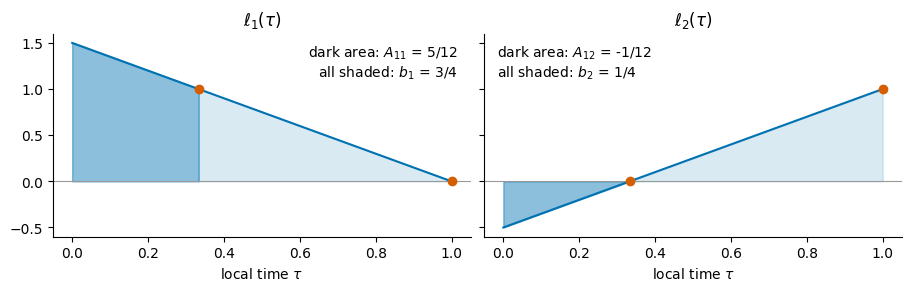

In [4]:
# @title Plot each basis function and the areas that form A and b
fig, axes = plt.subplots(1, len(tau), figsize=(4.5 * len(tau), 2.8), squeeze=False,
                         sharey=True, constrained_layout=True)
grid = np.linspace(0, 1, 200)
for j, (ax, ell) in enumerate(zip(axes[0], lagrange_basis(tau))):
    to_node, to_end = np.linspace(0, tau[0], 50), np.linspace(tau[0], 1, 100)
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.fill_between(to_node, ell(to_node), color="#0072B2", alpha=0.45)
    ax.fill_between(to_end, ell(to_end), color="#0072B2", alpha=0.15)
    ax.plot(grid, ell(grid), color="#0072B2")
    ax.plot(tau, ell(tau), "o", color="#D55E00")
    ax.set(xlabel=r"local time $\tau$", title=rf"$\ell_{{{j + 1}}}(\tau)$")
    label = (rf"dark area: $A_{{1{j + 1}}}$ = {frac(A[0, j])}" "\n"
             rf"all shaded: $b_{{{j + 1}}}$ = {frac(b[j])}")
    left = ell(0) < ell(1)          # write the label on the side where the curve is low
    ax.text(0.03 if left else 0.97, 0.95, label, transform=ax.transAxes,
            ha="left" if left else "right", va="top")
plt.show()

The orange dots mark the nodes, where each basis function equals one or zero.
The entry $A_{12}=-\tfrac{1}{12}$ is negative because $\ell_2$ is negative
between $0$ and $\tfrac{1}{3}$, and a negative weight is not an error. The
interpolated slope is a line through $\mathbf f_{k,1}$ at $\tau=\tfrac{1}{3}$
and $\mathbf f_{k,2}$ at $\tau=1$. Increasing $\mathbf f_{k,2}$ while
$\mathbf f_{k,1}$ stays fixed tilts this line upward to the right of
$\tau=\tfrac{1}{3}$ and downward to its left, so the state gains less before
the first node.

Any distinct nodes produce a valid rule, but the choice affects accuracy. The
Radau nodes make the weights $b$ integrate every polynomial of degree up to
two exactly. For example,
$\tfrac{3}{4}(\tfrac{1}{3})^2+\tfrac{1}{4}(1)^2=\tfrac{1}{3}$, which equals
$\int_0^1\tau^2d\tau$. Two nodes at the ends of the interval, which give the
trapezoidal rule, integrate only polynomials of degree up to one exactly. The
experiments at the end compare several node choices on the pendulum.

The arrays $A$ and $b$ are computed once, before any optimization, and stay
fixed while the optimizer searches.

## Step 2: Allocate the Variables

The rule needs the slopes at the nodes,
$\mathbf f_{k,j}=\mathbf f(\mathbf x_{k,j},u_k)$, and those depend on the
states at the nodes, which are unknown before the problem is solved. Direct
collocation does not compute these states by simulation. It makes them
unknowns of the optimization and adds equations, in Step 3, that make them
consistent. On interval $k$ the unknowns are a mesh state, the stage
states, and a torque. The diagram after the next code cell shows them with
their names in the code and their places in the vector $\mathbf z$.

The **mesh state** $\mathbf x_k$ is the state at the left end $t_k$. The
preceding interval ends at the same time and uses the same variable, and this
sharing keeps the trajectory continuous. The **stage states**
$\mathbf x_{k,1}$ and $\mathbf x_{k,2}$ are the states at the two nodes. The
torque $u_k$ is held constant over the interval, a choice called a
**zero-order hold** and the simplest control representation. In the chapter's notation, the control matrix $B$ is
then a column of ones. A linear or quadratic torque would add numbers per
interval without changing the construction of the state.

All states and torques are unknowns at the same time, and no simulation runs
inside the optimizer. This is why direct collocation is called a simultaneous
method. In single shooting, by contrast, the optimizer chooses only the
torques, and a time integrator computes the states.

Python counts from zero, so the stage state $\mathbf x_{k,j}$ is stored in
`x_stage[k, j-1]`. The solver needs all unknowns in one flat vector
$\mathbf z$, and the function `unpack` cuts that vector into the three arrays.

In [5]:
N = 40                              # intervals
h = T / N                           # interval width
s = len(tau)                        # stages per interval
n = len(x_start)                    # state dimension
n_z = (N + 1) * n + N * s * n + N   # number of unknowns


def unpack(z):
    x_mesh = z[:(N + 1) * n].reshape(N + 1, n)      # x_mesh[k] is the mesh state x_k
    x_stage = z[(N + 1) * n:-N].reshape(N, s, n)    # x_stage[k, j] is a stage state
    u = z[-N:]                                      # u[k] is the torque on interval k
    return x_mesh, x_stage, u


print("number of unknowns:", n_z)

number of unknowns: 282


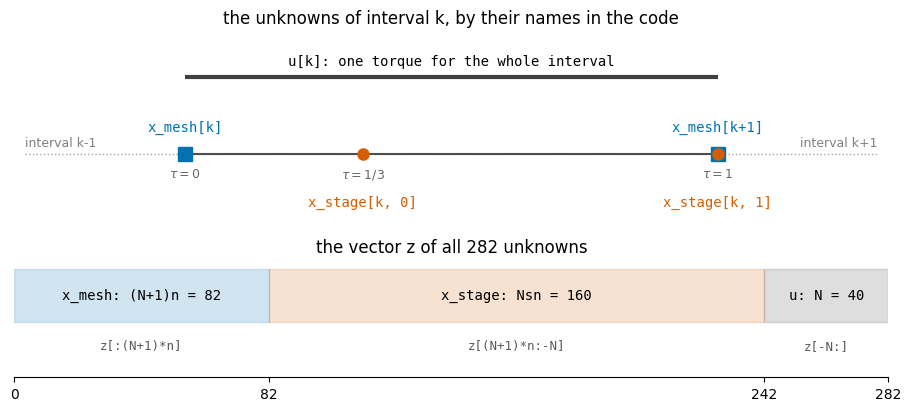

In [6]:
# @title Draw the unknowns of one interval and their places in z
fig, (interval, vector) = plt.subplots(2, 1, figsize=(9, 4.0), height_ratios=[1.7, 1],
                                       constrained_layout=True)
mono = dict(family="monospace", fontsize=10)

# One interval in local time, with the unknowns that belong to it.
interval.plot([-0.3, 1.3], [0, 0], color="0.65", linewidth=1, linestyle=":")
interval.plot([0, 1], [0, 0], color="0.3", linewidth=1.5)
interval.plot([0, 1], [0, 0], "s", color="#0072B2", markersize=10, zorder=3)
interval.plot(tau, np.zeros(s), "o", color="#D55E00", markersize=8, zorder=4)
interval.text(0, 0.3, "x_mesh[k]", ha="center", color="#0072B2", **mono)
interval.text(1, 0.3, "x_mesh[k+1]", ha="center", color="#0072B2", **mono)
for j, node in enumerate(tau):
    interval.text(node, -0.55, f"x_stage[k, {j}]", ha="center", va="top", color="#D55E00", **mono)
for point in sorted({0.0, *tau, 1.0}):
    interval.text(point, -0.18, rf"$\tau={frac(point)}$", ha="center", va="top", color="0.4",
                  fontsize=9)
interval.plot([0, 1], [1.0, 1.0], color="0.25", linewidth=3, solid_capstyle="butt")
interval.text(0.5, 1.12, "u[k]: one torque for the whole interval", ha="center", va="bottom",
              **mono)
interval.text(-0.3, 0.1, "interval k-1", color="0.5", fontsize=9)
interval.text(1.3, 0.1, "interval k+1", color="0.5", fontsize=9, ha="right")
interval.set(xlim=(-0.32, 1.32), ylim=(-1.0, 1.6), xticks=[], yticks=[],
             title="the unknowns of interval k, by their names in the code")
interval.axis("off")

# The vector z: the three arrays laid end to end, as unpack reads them.
sizes = [(N + 1) * n, N * s * n, N]
labels = [f"x_mesh: (N+1)n = {sizes[0]}", f"x_stage: Nsn = {sizes[1]}", f"u: N = {sizes[2]}"]
slices = ["z[:(N+1)*n]", "z[(N+1)*n:-N]", "z[-N:]"]
start = 0
for size, label, piece, color in zip(sizes, labels, slices, ["#0072B2", "#D55E00", "0.3"]):
    vector.barh(0, size, left=start, height=0.9, color=color, alpha=0.18, edgecolor=color)
    vector.text(start + size / 2, 0, label, ha="center", va="center", **mono)
    vector.text(start + size / 2, -0.75, piece, ha="center", va="top", color="0.35",
                family="monospace", fontsize=9)
    start += size
vector.set(xlim=(0, n_z), ylim=(-1.4, 0.6), yticks=[], xticks=np.cumsum([0, *sizes]),
           title=f"the vector z of all {n_z} unknowns")
vector.spines[["left"]].set_visible(False)
plt.show()

> **For the exam.** Count the unknowns of a collocation transcription from
> the number of intervals $N$, the number of nodes $s$, the state dimension
> $n$, and the control representation. Here the count is $(N+1)n+Nsn+N$,
> which is $41\cdot2+40\cdot2\cdot2+40=282$: the mesh states, the stage
> states, and one torque per interval. Step 3 counts the equations in the
> same way.

## Step 3: Assemble Each Interval

The slopes $\mathbf f_{k,j}=\mathbf f(\mathbf x_{k,j},u_k)$ are now computed
from the unknowns, so they change whenever the optimizer changes
$\mathbf z$. The rule $A$, $b$ does not change. On each interval, the
unknowns must satisfy the chapter's **stage equations** and **endpoint
equation**:

$$
\mathbf x_{k,i}=\mathbf x_k+h\sum_{j=1}^{s}A_{ij}\mathbf f_{k,j},
\qquad
\mathbf x_{k+1}=\mathbf x_k+h\sum_{j=1}^{s}b_j\mathbf f_{k,j}.
$$

> **Question.** Stop here before reading on. Where do these two equations
> come from? Derive them from the results of Step 1.

:::{dropdown} Answer
Step 1 showed that integrating the interpolated slopes from the left end gives
the state inside the interval:

$$
\mathbf x(t_k+h\tau)\approx\mathbf x_k
+h\sum_{j=1}^{s}\mathbf f_{k,j}\int_0^{\tau}\ell_j(\sigma)d\sigma .
$$

Setting $\tau=\tau_i$ turns each integral into $A_{ij}$, and the right side
becomes the value of the polynomial at node $i$. Requiring that value to equal
the stored stage state $\mathbf x_{k,i}$ gives the stage equation. Setting
$\tau=1$ turns each integral into $b_j$, and the right side becomes the value
at the right end. Requiring that value to equal the next mesh state
$\mathbf x_{k+1}$ gives the endpoint equation.

:::

The stage equation for node $i$ requires the stored stage state
$\mathbf x_{k,i}$ to lie on the polynomial built from the slopes. It is needed
because the slopes were evaluated at the stored stage states. If those states
could differ from the polynomial's values, the slopes would describe some other
trajectory. When the stage equation holds, the polynomial has the value
$\mathbf x_{k,i}$ at node $i$, and its slope there is $\mathbf f_{k,i}$ by
construction of the interpolant. The polynomial therefore satisfies the
differential equation at node $i$. This is where the name comes from: to
collocate is to place together, from the Latin *com-* (together) and *locare*
(to place). A collocation method places the approximation and the
differential equation together at the chosen nodes, where they must agree
exactly. Between the nodes, nothing forces them to agree.

The endpoint equation requires the next mesh state to equal the value of the
polynomial at the right end of the interval. The difference between its two
sides is called the **defect**. Because $\mathbf x_{k+1}$ is also the starting
state of interval $k+1$, a zero defect joins consecutive pieces into one
continuous trajectory.

With the numbers from Step 1, the three equations read

$$
\begin{aligned}
\mathbf x_{k,1}&=\mathbf x_k
+h\left(\tfrac{5}{12}\mathbf f_{k,1}-\tfrac{1}{12}\mathbf f_{k,2}\right),\cr
\mathbf x_{k,2}&=\mathbf x_k
+h\left(\tfrac{3}{4}\mathbf f_{k,1}+\tfrac{1}{4}\mathbf f_{k,2}\right),\cr
\mathbf x_{k+1}&=\mathbf x_k
+h\left(\tfrac{3}{4}\mathbf f_{k,1}+\tfrac{1}{4}\mathbf f_{k,2}\right).
\end{aligned}
$$

The first two use the rows of $A$ and the third uses $b$. The second and
third equations have the same right side because $\tau_2=1$. The second row
of $A$ integrates each basis function from $0$ to $\tau_2=1$, which is the
same integral that defines $b$, so $A_{2j}=b_j$: both rows are
$(\tfrac{3}{4},\tfrac{1}{4})$. Two quantities equal to the same expression
are equal to each other, so the equations imply
$\mathbf x_{k,2}=\mathbf x_{k+1}$. This matches the picture: node 2 sits at
the right end of the interval, so the state there is the next mesh state. The code keeps both variables and both
equations anyway, so that it stays valid for nodes that do not include the
right end.

The objective is built the same way. The cost accumulated since time $0$
behaves like an extra state whose slope is the cost rate $c(\mathbf x,u)$,
and the same rule integrates it. Its stage equations would use the rows of
$A$ and give the cost accumulated up to each node. The objective needs only
the total over each interval, which is the value at the right end, so only
the weights $b$ appear. Interval $k$ adds
$h(\tfrac{3}{4}c_{k,1}+\tfrac{1}{4}c_{k,2})$ to the objective, where
$c_{k,j}=c(\mathbf x_{k,j},u_k)$. Here $c=u_k^2$ is constant on the interval
and the weights sum to one, so this sum equals $hu_k^2$, the exact integral of
the squared torque over the interval. The boundary conditions
$\mathbf x_0=(0,0)$ and $\mathbf x_N=(\pi,0)$ and the torque limits
$-u_{\max}\le u_k\le u_{\max}$ complete the finite problem. Because the torque
is constant on each interval, bounding each $u_k$ bounds the torque at every
instant, not only at the nodes.

In [7]:
def objective(z):                                                       # F(z)
    x_mesh, x_stage, u = unpack(z)
    return sum(h * b[j] * c(x_stage[k, j], u[k]) for k in range(N) for j in range(s))


def equalities(z):                                                      # H(z) = 0
    x_mesh, x_stage, u = unpack(z)
    residuals = [x_mesh[0] - x_start, x_mesh[N] - x_goal]               # boundary conditions
    for k in range(N):
        slopes = np.array([f(x_stage[k, j], u[k]) for j in range(s)])   # f at every stage
        residuals.append(x_stage[k] - x_mesh[k] - h * A @ slopes)       # stage equations
        residuals.append(x_mesh[k + 1] - x_mesh[k] - h * b @ slopes)    # endpoint equation
    return np.concatenate([r.ravel() for r in residuals])


print("number of equations:", equalities(np.zeros(n_z)).size)

number of equations: 244


In `equalities`, the array `slopes` has one row per stage and one column per
state component. The product `A @ slopes` computes all the sums
$\sum_jA_{ij}\mathbf f_{k,j}$ at once, one row per node $i$, and `b @ slopes`
computes the endpoint sum. Each residual is written as left side minus right
side, so a solution makes it zero. The last line flattens the residuals into
the single vector $H(\mathbf z)$ that the solver expects.

The count of equations explains what the optimizer is free to choose. The 240
stage and endpoint equations match the 240 states other than $\mathbf x_0$,
so for a given initial state and given torques they determine the whole
trajectory, as a simulation would. The torque is a zero-order hold with one
value on each of the 40 intervals, so the optimizer chooses 40 torques. The
four boundary equations fix $\mathbf x_0$ and impose two terminal conditions,
which remove two of those choices and leave $40-2=38$ degrees of freedom. The
torque limits are inequalities, not equations: they do not change this count,
but they rule out part of that family. Among the torque sequences that bring
the pendulum to the goal within the limits, the objective selects the one
with the least effort.

The table collects the correspondence between the chapter's symbols and the
code.

| Chapter | Code | Meaning |
|:--|:--|:--|
| $\tau_j$ | `tau[j-1]` | collocation node $j$, in local time |
| $\ell_j$, $L_j$ | `lagrange_basis(tau)[j-1]`, `L[j-1]` | basis function and its antiderivative |
| $A_{ij}$, $b_j$ | `A[i-1, j-1]`, `b[j-1]` | the rule: weights of the slopes |
| $h$ | `h` | interval width |
| $\mathbf x_k$ | `x_mesh[k]` | state at the mesh time $t_k$ |
| $\mathbf x_{k,j}$ | `x_stage[k, j-1]` | state at node $j$ of interval $k$ |
| $u_k$ | `u[k]` | torque on interval $k$ |
| $\mathbf f_{k,j}$ | `slopes[j-1]` | ODE slope at node $j$ of interval $k$ |
| $\mathbf z$ | `z` | all unknowns in one vector |
| $F(\mathbf z)$, $H(\mathbf z)$ | `objective(z)`, `equalities(z)` | objective and equality residuals |

## Step 4: Connect the Controls

The state must be continuous, because it is obtained by integrating its rate
of change, but the control need not be. A motor command can jump from one
value to the next, as it does here between intervals, so no equation links
$u_k$ to $u_{k+1}$. State continuity needs no extra equation either, because
consecutive intervals share the mesh state $\mathbf x_{k+1}$. A smooth torque
could be obtained by making it linear on each interval and sharing its
endpoint values between intervals.

## Step 5: Solve and Check

The solver needs a starting point. The initial guess moves the states along a
straight line from the start to the goal and sets the torque to zero. This is
not a motion of the pendulum: without torque the pendulum would stay hanging.
The largest residual at the guess, printed below, measures how far the guess
is from satisfying the equations. A simultaneous method can start from such an
infeasible guess, which only has to describe roughly where the motion should
go. Such a guess is often easier to provide than a good torque sequence.

SciPy's SLSQP method then improves $\mathbf z$ step by step. At each iteration
it approximates $F$ by a quadratic function and $H$ by a linear one, solves
that approximation for a step, and repeats. Intermediate iterates need not
satisfy $H(\mathbf z)=\mathbf 0$; at convergence the residuals are zero up to
the solver's tolerance. SLSQP estimates the derivatives of `objective` and
`equalities` by finite differences, which is adequate for 282 unknowns.
Larger problems supply exact derivatives, for example by automatic
differentiation, and use solvers that exploit the sparsity of the equations.

The torque limits reach the solver as bounds. SLSQP accepts one
(lower, upper) pair per entry of $\mathbf z$, with `None` for no bound: the
states are free, and each of the last $N$ entries, the torques, must lie in
$[-u_{\max},u_{\max}]$. The option `ftol=1e-10` asks for a tighter tolerance
than SLSQP's default, so that the two formulations compared at the end of the
demo agree closely.

In [8]:
t = np.linspace(0, T, N + 1)                   # mesh times
t_stage = t[:-1, None] + h * tau               # stage times, shape (N, s)
z0 = np.concatenate([
    np.outer(t, x_goal / T).ravel(),           # mesh states on a straight line
    np.outer(t_stage, x_goal / T).ravel(),     # stage states on the same line
    np.zeros(N),                               # zero torque
])
bounds = [(None, None)] * (len(z0) - N) + [(-u_max, u_max)] * N   # limits on the torques
print(f"largest residual at the initial guess = {abs(equalities(z0)).max():.2f}")

solution = minimize(objective, z0, method="SLSQP", bounds=bounds, options={"ftol": 1e-10},
                    constraints={"type": "eq", "fun": equalities})
x_mesh, x_stage, u = unpack(solution.x)
print(solution.message)
print(f"cost = {solution.fun:.4f}")
print(f"largest torque used = {abs(u).max():.2f}")
print(f"largest residual = {abs(equalities(solution.x)).max():.1e}")

largest residual at the initial guess = 0.20


Optimization terminated successfully
cost = 1.4429
largest torque used = 0.50
largest residual = 1.5e-12


> **For the exam.** A small residual does not mean that the trajectory is
> accurate. Explain why, and say how to check accuracy.

The residual measures one thing: how far the stored numbers are from
satisfying the collocation equations. The solver drives it down to its
tolerance. Those equations are not the differential equation. They require
the ODE only at the nodes, and they replace the integrand by its polynomial
interpolant, so even an exact solution of the equations differs from the true
motion under the same torques. This **discretization error** depends on the
interval width and the nodes, not on the solver, so tightening the solver's
tolerance does not reduce it. To measure it, the next cell applies the
optimized torques to the pendulum with an accurate ODE solver and compares
the result with the stored states. This
replay is one of the checks described in the chapter's section on
[checking the continuous trajectory](https://pierrelux.github.io/rlbook/continuous-time-collocation#sec-collocation-validation).

In [9]:
def replay(u):
    # Integrate the ODE accurately under the piecewise-constant torques.
    states = [x_start]
    for k in range(N):
        step = solve_ivp(lambda _, x: f(x, u[k]), [0, h], states[-1], rtol=1e-10, atol=1e-10)
        states.append(step.y[:, -1])
    return np.array(states)


x_replay = replay(u)
print(f"largest difference from the replay = {abs(x_mesh - x_replay).max():.1e}")

largest difference from the replay = 4.4e-03


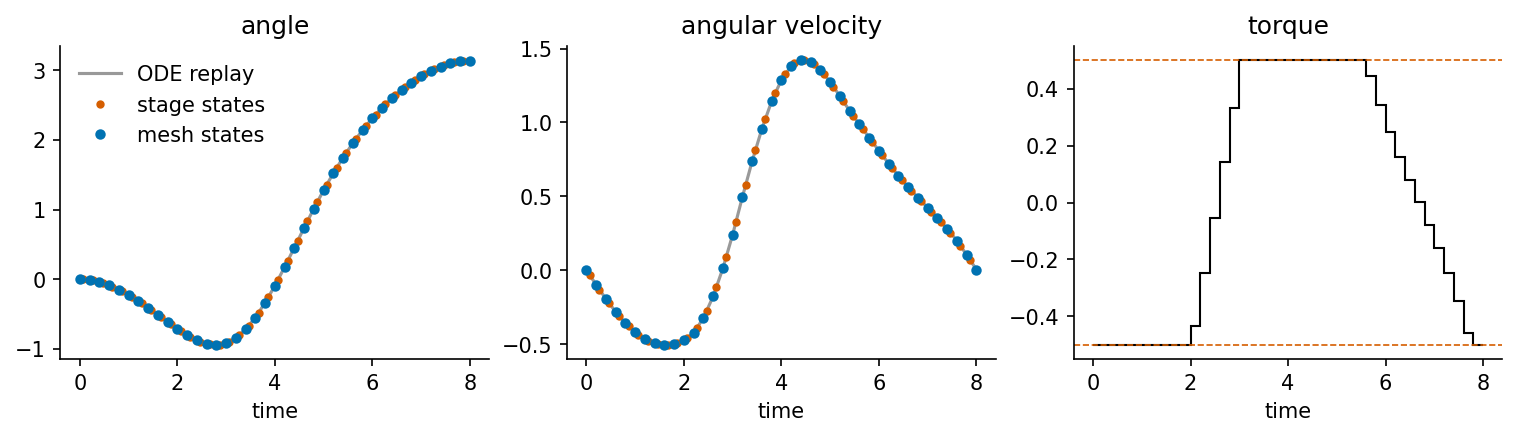

In [10]:
# @title Plot the stored states, the replay, and the torque
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), constrained_layout=True, dpi=150)
for i, name in enumerate(["angle", "angular velocity"]):
    axes[i].plot(t, x_replay[:, i], color="0.6", label="ODE replay")
    axes[i].plot(t_stage.ravel(), x_stage[:, :, i].ravel(), ".", color="#D55E00",
                 label="stage states")
    axes[i].plot(t, x_mesh[:, i], "o", color="#0072B2", markersize=4, label="mesh states")
    axes[i].set(xlabel="time", title=name)
axes[0].legend(frameon=False)
axes[2].stairs(u, t, baseline=None, color="black")
for limit in (-u_max, u_max):                       # the torque limits
    axes[2].axhline(limit, color="#D55E00", linewidth=0.8, linestyle="--")
axes[2].set(xlabel="time", title="torque")
plt.show()

The difference from the replay, about $4\times10^{-3}$, is the
discretization error of 40 intervals with the Radau rule. The second
experiment at the end shows how quickly it decreases as the number of
intervals grows.

In the figure, the grey curves are the replayed pendulum, the dots are the
stored states, and the dashed lines mark the torque limits. The dots lie on the curves, and the pendulum arrives upright
and at rest. The torque shows how a weak motor swings a pendulum up. For the
first two seconds it pushes backward at the limit $-0.5$, and the pendulum
swings back to about $-54^\circ$, which it reaches at $t\approx2.8$. The
torque reverses just before the pendulum turns around, and from $t=3$ to
$t\approx5.6$ it pushes forward at the limit $+0.5$ while the pendulum swings
through the bottom and climbs. Near the top the motor eases off and then
brakes, so that the pendulum arrives at rest instead of swinging past the
upright position.

The animation below shows the same replay as a motion: the optimized torques
drive the pendulum from hanging at rest to upright at rest. It is computed by
the accurate ODE solver, not read from the stored values, so it shows what the
torques actually do to the pendulum. Press play, or drag the slider to step
through time.

In [11]:
# @title Animate the pendulum under the optimized torques
from matplotlib import animation
from IPython.display import HTML

# Replay the optimized torques again, keeping two frames per interval.
times, states = [0.0], [x_start]
for k in range(N):
    step = solve_ivp(lambda _, x: f(x, u[k]), [0, h], states[-1], t_eval=np.linspace(0, h, 3)[1:],
                     rtol=1e-10, atol=1e-10)
    times.extend(t[k] + step.t)
    states.extend(step.y.T)
theta = np.array(states)[:, 0]

fig, (scene, torque_axis) = plt.subplots(1, 2, figsize=(7.5, 3.4), width_ratios=[1, 1.3],
                                         constrained_layout=True, dpi=72)
scene.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal")
scene.axis("off")
scene.plot(np.sin(theta), -np.cos(theta), color="0.85", linewidth=1)        # path of the bob
scene.plot([0], [1], "x", color="#D55E00", markersize=9)                     # upright goal
rod, = scene.plot([], [], color="0.25", linewidth=3)
bob, = scene.plot([], [], "o", color="#0072B2", markersize=14)
clock = scene.text(-1.25, 1.25, "", va="top", family="monospace", fontsize=9)
torque_axis.stairs(u, t, baseline=None, color="black")
for limit in (-u_max, u_max):                       # the torque limits
    torque_axis.axhline(limit, color="0.6", linewidth=0.8, linestyle="--")
torque_axis.set(xlabel="time", title="torque")
now = torque_axis.axvline(0, color="#D55E00")

def draw(i):
    x, y = np.sin(theta[i]), -np.cos(theta[i])
    rod.set_data([0, x], [0, y])
    bob.set_data([x], [y])
    clock.set_text(f"t = {times[i]:.2f}")
    now.set_xdata([times[i]])
    return rod, bob, clock, now

movie = animation.FuncAnimation(fig, draw, frames=len(times), interval=1000 * h / 2)  # real time
plt.close(fig)
HTML(movie.to_jshtml(default_mode="once"))

> **Question.** Why does the pendulum swing backward first, instead of
> going straight up? Compare the torque limit with the largest torque that
> gravity can exert, and think about the pendulum's energy.

:::{dropdown} Answer
Gravity exerts the torque $-\sin\theta$, whose largest magnitude is $1$, reached
when the pendulum is horizontal. The motor's limit is $0.5$, so it cannot even
hold the pendulum horizontal, let alone push it straight up.

The energy explains the back swing. The pendulum's energy
$E=\tfrac{1}{2}\omega^2+1-\cos\theta$ is $0$ when it hangs at rest and $2$ when
it stands upright at rest. Its rate of change is $\dot E=u\omega$, so the work
of the motor is $\int u\omega dt=\int u d\theta$, at most $0.5$ times the total
angle the pendulum travels. Going straight from $0$ to $\pi$ travels the angle
$\pi$ and gains at most $0.5\pi\approx1.57$, less than the $2$ needed. Swinging
back to $-0.95$ first makes the pendulum travel about
$0.95+0.95+\pi\approx5.04$, which allows up to $0.5\times5.04\approx2.5$. The
back swing pumps energy into the pendulum.

A pendulum with a motor at its pivot has one degree of freedom and one
actuator, so it is fully actuated. With a torque limit below the largest
gravity torque, it behaves like the underactuated systems of robotics, which
must pump energy in this way. The third experiment at the end raises the
limit above $1$ to show the difference.

:::

## The Same Construction with Derivatives

In the integration form above, the slopes are matched by design: the
interpolated slope takes the value $\mathbf f_{k,j}$ at each node. What must
be enforced is the consistency of the states. Integrating the interpolated
slope from the mesh state $\mathbf x_k$ to node $i$ reconstructs a state value
there, and the stage equation requires that reconstructed value to equal the
stage state $\mathbf x_{k,i}$ that the optimizer holds as a decision variable.
The chapter's
[differentiation form](https://pierrelux.github.io/rlbook/continuous-time-collocation#alg-collocation-differentiation-from-nodes)
reverses the roles. It builds the polynomial through the stored state values,
so the states are matched by design, and it enforces the slopes: the
derivative of that polynomial must equal the ODE slope at each node. At a solution, both forms
express the same two facts: the polynomial passes through the stored states,
and its slope equals $\mathbf f$ at each node. They differ in which fact holds
by construction and which becomes a constraint.

With $s$ nodes, the interpolated slope has degree $s-1$, so the state
polynomial, its integral, has degree $s$, and $s+1$ values determine it. In
this demo $s=2$: the slope is a line, the state is a quadratic, and three
values determine it. Store its values at $\tau=0$ and at the two collocation
nodes. These are $\mathbf x_k$,
$\mathbf x_{k,1}$, and $\mathbf x_{k,2}$, the same unknowns as before, so
$\mathbf z$, `unpack`, and `objective` do not change.

Let $\ell_0,\ell_1,\ell_2$ now denote the Lagrange basis for the three points
$(0,\tfrac{1}{3},1)$, and write $\mathbf x_{k,0}=\mathbf x_k$ for the stored
value at $\tau=0$. The quadratic through the three stored values is their
Lagrange interpolant:

$$
\mathbf p_k(\tau)=\sum_{r=0}^{s}\mathbf x_{k,r}\ell_r(\tau).
$$

The stored values are constants, so differentiating this sum differentiates
only the basis functions, by the same linearity as in Step 1. At node $i$,

$$
\mathbf p_k'(\tau_i)=\sum_{r=0}^{s}\ell_r'(\tau_i)\mathbf x_{k,r}
=\sum_{r=0}^{s}D_{ir}\mathbf x_{k,r},
\qquad
D_{ir}=\ell_r'(\tau_i).
$$

The numbers $D_{ir}$ depend only on the points, like $A$ and $b$, and they
turn the three stored values into the exact slope of the quadratic at node
$i$. That slope is measured per unit of local time. Since $t=t_k+h\tau$, the
chain rule gives the physical-time slope $\tfrac{1}{h}\mathbf p_k'(\tau)$.
Requiring it to equal the ODE slope at node $i$, and multiplying by $h$,
gives the slope equations

$$
\sum_{r=0}^{s}D_{ir}\mathbf x_{k,r}=h\mathbf f_{k,i}.
$$

By hand, the basis functions are

$$
\ell_0(\tau)=3\tau^2-4\tau+1,\qquad
\ell_1(\tau)=-\tfrac{9}{2}\tau^2+\tfrac{9}{2}\tau,\qquad
\ell_2(\tau)=\tfrac{3}{2}\tau^2-\tfrac{1}{2}\tau,
$$

with derivatives $6\tau-4$, $-9\tau+\tfrac{9}{2}$, and $3\tau-\tfrac{1}{2}$.
Evaluating these derivatives at $\tfrac{1}{3}$ and at $1$ gives one row of $D$
per collocation node, and hence the two slope equations:

$$
D=\begin{bmatrix}
-2&\tfrac{3}{2}&\tfrac{1}{2}\cr
2&-\tfrac{9}{2}&\tfrac{5}{2}
\end{bmatrix},
\qquad
\begin{aligned}
-2\mathbf x_k+\tfrac{3}{2}\mathbf x_{k,1}+\tfrac{1}{2}\mathbf x_{k,2}
&=h\mathbf f_{k,1},\cr
2\mathbf x_k-\tfrac{9}{2}\mathbf x_{k,1}+\tfrac{5}{2}\mathbf x_{k,2}
&=h\mathbf f_{k,2}.
\end{aligned}
$$

Each row of $D$ sums to zero, because a constant state has zero slope. The
endpoint equation evaluates the quadratic at $\tau=1$ with the weights
$e_r=\ell_r(1)$. Here $e=(0,0,1)$ because $\tau=1$ is one of the stored
points, so the equation reduces to $\mathbf x_{k+1}=\mathbf x_{k,2}$.
Compared with the integration form, only the rule and two lines of the
constraint function change.

In [12]:
assert tau.min() > 0, "this section needs collocation nodes other than 0"

# D[i, r] is the slope of ell_r at tau_i, and e[r] is the value of ell_r at 1.
state_basis = lagrange_basis(np.append(0.0, tau))    # basis for the points 0, tau_1, ..., tau_s
D = np.array([[ell.deriv()(tau_i) for ell in state_basis] for tau_i in tau])
e = np.array([ell(1.0) for ell in state_basis])
show("D", D)
show("e", e)


def equalities_from_derivatives(z):                                     # H(z) = 0
    x_mesh, x_stage, u = unpack(z)
    residuals = [x_mesh[0] - x_start, x_mesh[N] - x_goal]               # boundary conditions
    for k in range(N):
        slopes = np.array([f(x_stage[k, j], u[k]) for j in range(s)])   # f at every stage
        values = np.vstack([x_mesh[k], x_stage[k]])                     # state at 0 and the nodes
        residuals.append(D @ values - h * slopes)                       # slope equations
        residuals.append(x_mesh[k + 1] - e @ values)                    # endpoint equation
    return np.concatenate([r.ravel() for r in residuals])


other = minimize(objective, z0, method="SLSQP", bounds=bounds, options={"ftol": 1e-10},
                 constraints={"type": "eq", "fun": equalities_from_derivatives})
print(f"cost = {other.fun:.4f}")
print(f"largest difference between the two solutions = {abs(other.x - solution.x).max():.1e}")

D = [[-2, 3/2, 1/2], [2, -9/2, 5/2]]
e = [0, 0, 1]


cost = 1.4429
largest difference between the two solutions = 1.3e-06


Both programs have the same unknowns and the same objective, and their
constraints vanish at the same points, so the solver returns the same
trajectory up to its tolerance. Away from a solution the two residual vectors
differ, which can change the solver's iterations but not the set of solutions.

## Experiments

Each experiment changes a few lines. Run all cells again after a change.

The first experiment replaces the nodes in Step 1. The same code then
produces the other schemes of the chapter, because only the numbers in $A$
and $b$ change. The table lists the largest difference from the replay
obtained with $N=40$.

| `tau` | Scheme | Difference from the replay |
|:--|:--|:--|
| `np.array([0.0])` | explicit Euler | $3$ |
| `np.array([1.0])` | implicit Euler | does not converge |
| `np.array([0.5])` | implicit midpoint | $5\times10^{-2}$ |
| `np.array([0.0, 1.0])` | trapezoidal | $2\times10^{-2}$ |
| `np.array([1/3, 1.0])` | Radau, two stages | $4\times10^{-3}$ |
| `0.5 + np.array([-1, 1]) * np.sqrt(3) / 6` | Gauss, two stages | $3\times10^{-5}$ |
| `np.array([0.0, 0.5, 1.0])` | Hermite-Simpson | $9\times10^{-6}$ |

Every row that converges satisfies its own collocation equations to the
solver's tolerance. The rows differ in how well those equations represent the
differential equation. Explicit Euler is the extreme case: the solver
satisfies its equations, and its cost is the lowest of all rows, yet its
torques drive the real pendulum nowhere near the top. Implicit Euler stops at
SLSQP's iteration limit with a residual near $0.04$. A likely reason is that
implicit Euler damps oscillations numerically, removing energy at every step,
so that its discrete pendulum cannot reach the top with the weak motor. A
node at $0$ runs through Step 5 and stops at the first line of
the last section, which stores the state at $0$ and at the collocation nodes
and needs these to be distinct. For the Gauss nodes, `show` prints rounded
fractions because the exact entries are irrational.

The second experiment refines the mesh. With the Radau nodes, set `N` to 10,
20, 40, and 80; the last takes about half a minute to solve. The difference
from the replay falls by a factor of about eight each time `N` doubles.

The third experiment makes the motor strong. Set `T = 4.0`, `N = 20`, and
`u_max = 1.5`, which is above the largest gravity torque. The solution then
uses torques up to about $1.35$ and never reaches the limit, so the bound is
inactive. The motor overpowers gravity at every angle, and the animation in
Step 5 shows the pendulum lifted straight up, without a back swing. The
collocation construction is the same; only the optimal motion changes.

## Summary

The demo turned a continuous-time problem into 282 numbers, 244 equations,
and limits on 40 of the numbers.
The rule $A$, $b$ depends only on the nodes and is computed once by exact
polynomial calculus. The stage equations make the polynomial on each interval
satisfy the ODE at the nodes, the endpoint equations join the pieces, and the
same weights integrate the cost. The solver's residual shows that the finite
equations hold, and the replay measures how well they represent the pendulum.
Changing the nodes, the number of intervals, or the model changes a line or a
cell, and the construction stays the same. The chapter
[Continuous-Time Transcription and Collocation](https://pierrelux.github.io/rlbook/continuous-time-collocation) develops each step in
general, including controls that vary within an interval and constraints
checked between nodes.